In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


import matplotlib.pyplot as plt
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

X=pd.read_csv("../data/X.csv")
y=pd.read_csv("../data/y.csv").squeeze()




In [ ]:
model_randomforest=RandomForestClassifier(random_state=42)
model_randomforest.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred=model_randomforest.predict(X_test)
y_prob=model_randomforest.predict_proba(X_test)[:,1]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_prob)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.9969024264326277
Precision: 0.9963898916967509
Recall: 0.999275887038378
F1 Score: 0.9978308026030369
ROC AUC: 0.9994746599534275


In [ ]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1112
           1       1.00      1.00      1.00      2762

    accuracy                           1.00      3874
   macro avg       1.00      1.00      1.00      3874
weighted avg       1.00      1.00      1.00      3874



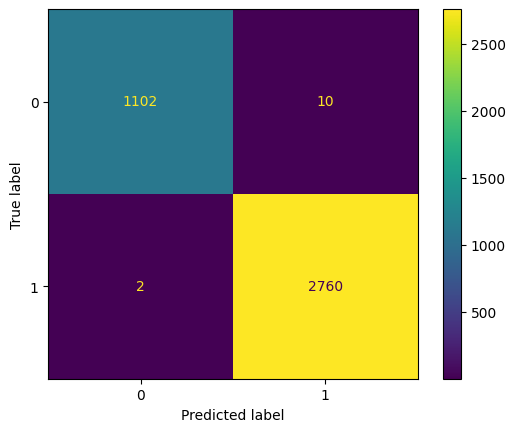

In [ ]:
confusion_matrix=confusion_matrix(y_test,y_pred)
dis=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix,display_labels=model_randomforest.classes_)
dis.plot()
plt.show()

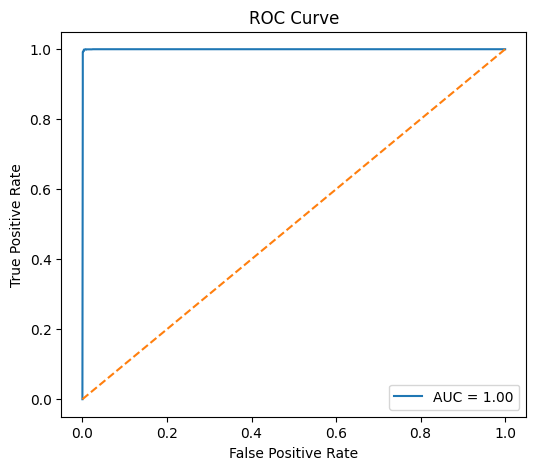

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

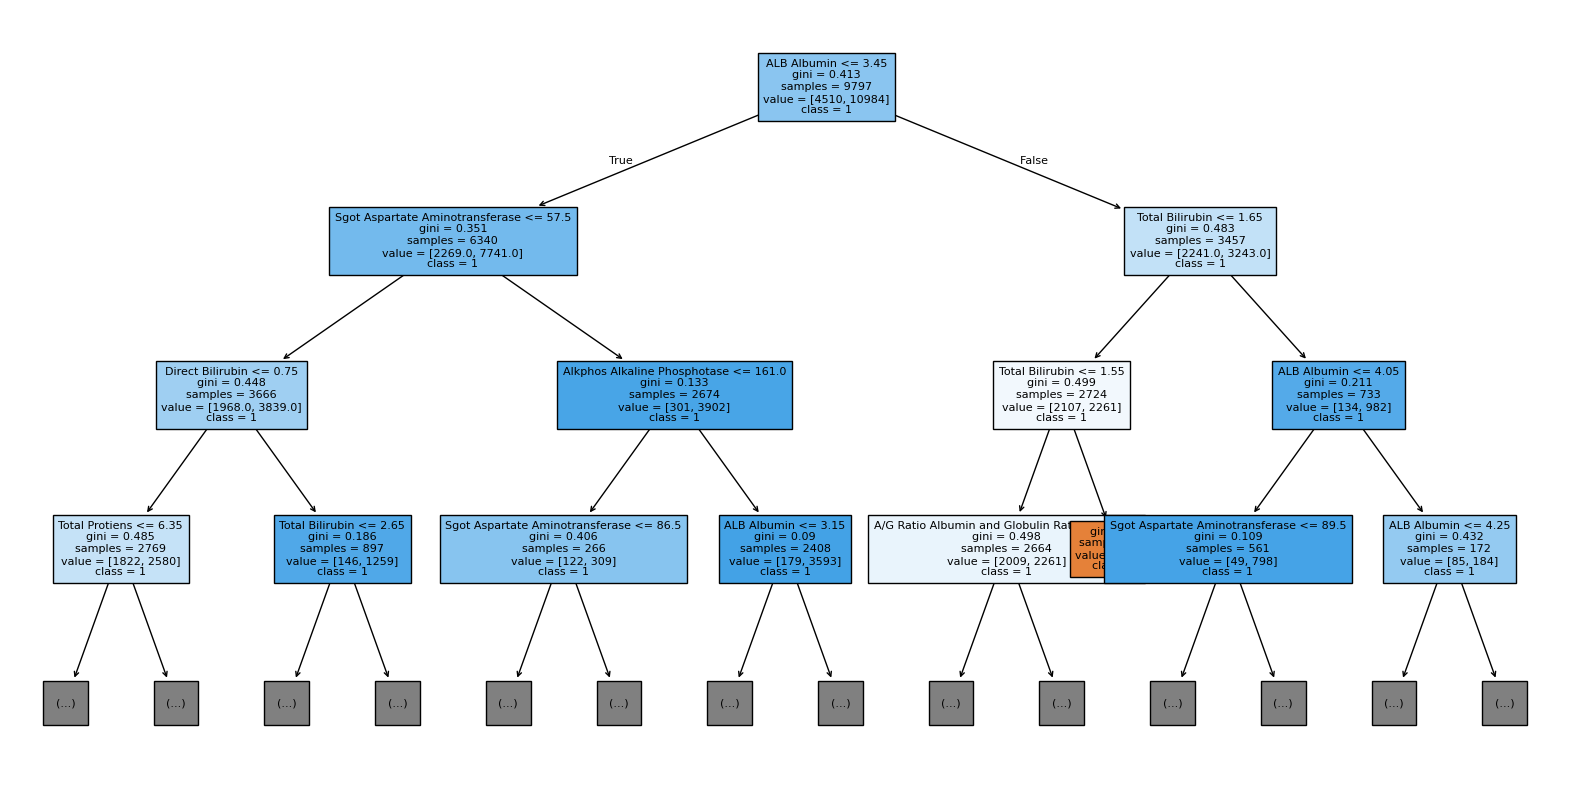

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model_randomforest.estimators_[0],
    filled=True,
    feature_names=X_train.columns,
    class_names=["0", "1"],
    max_depth=3,
    fontsize=8
)

plt.show()

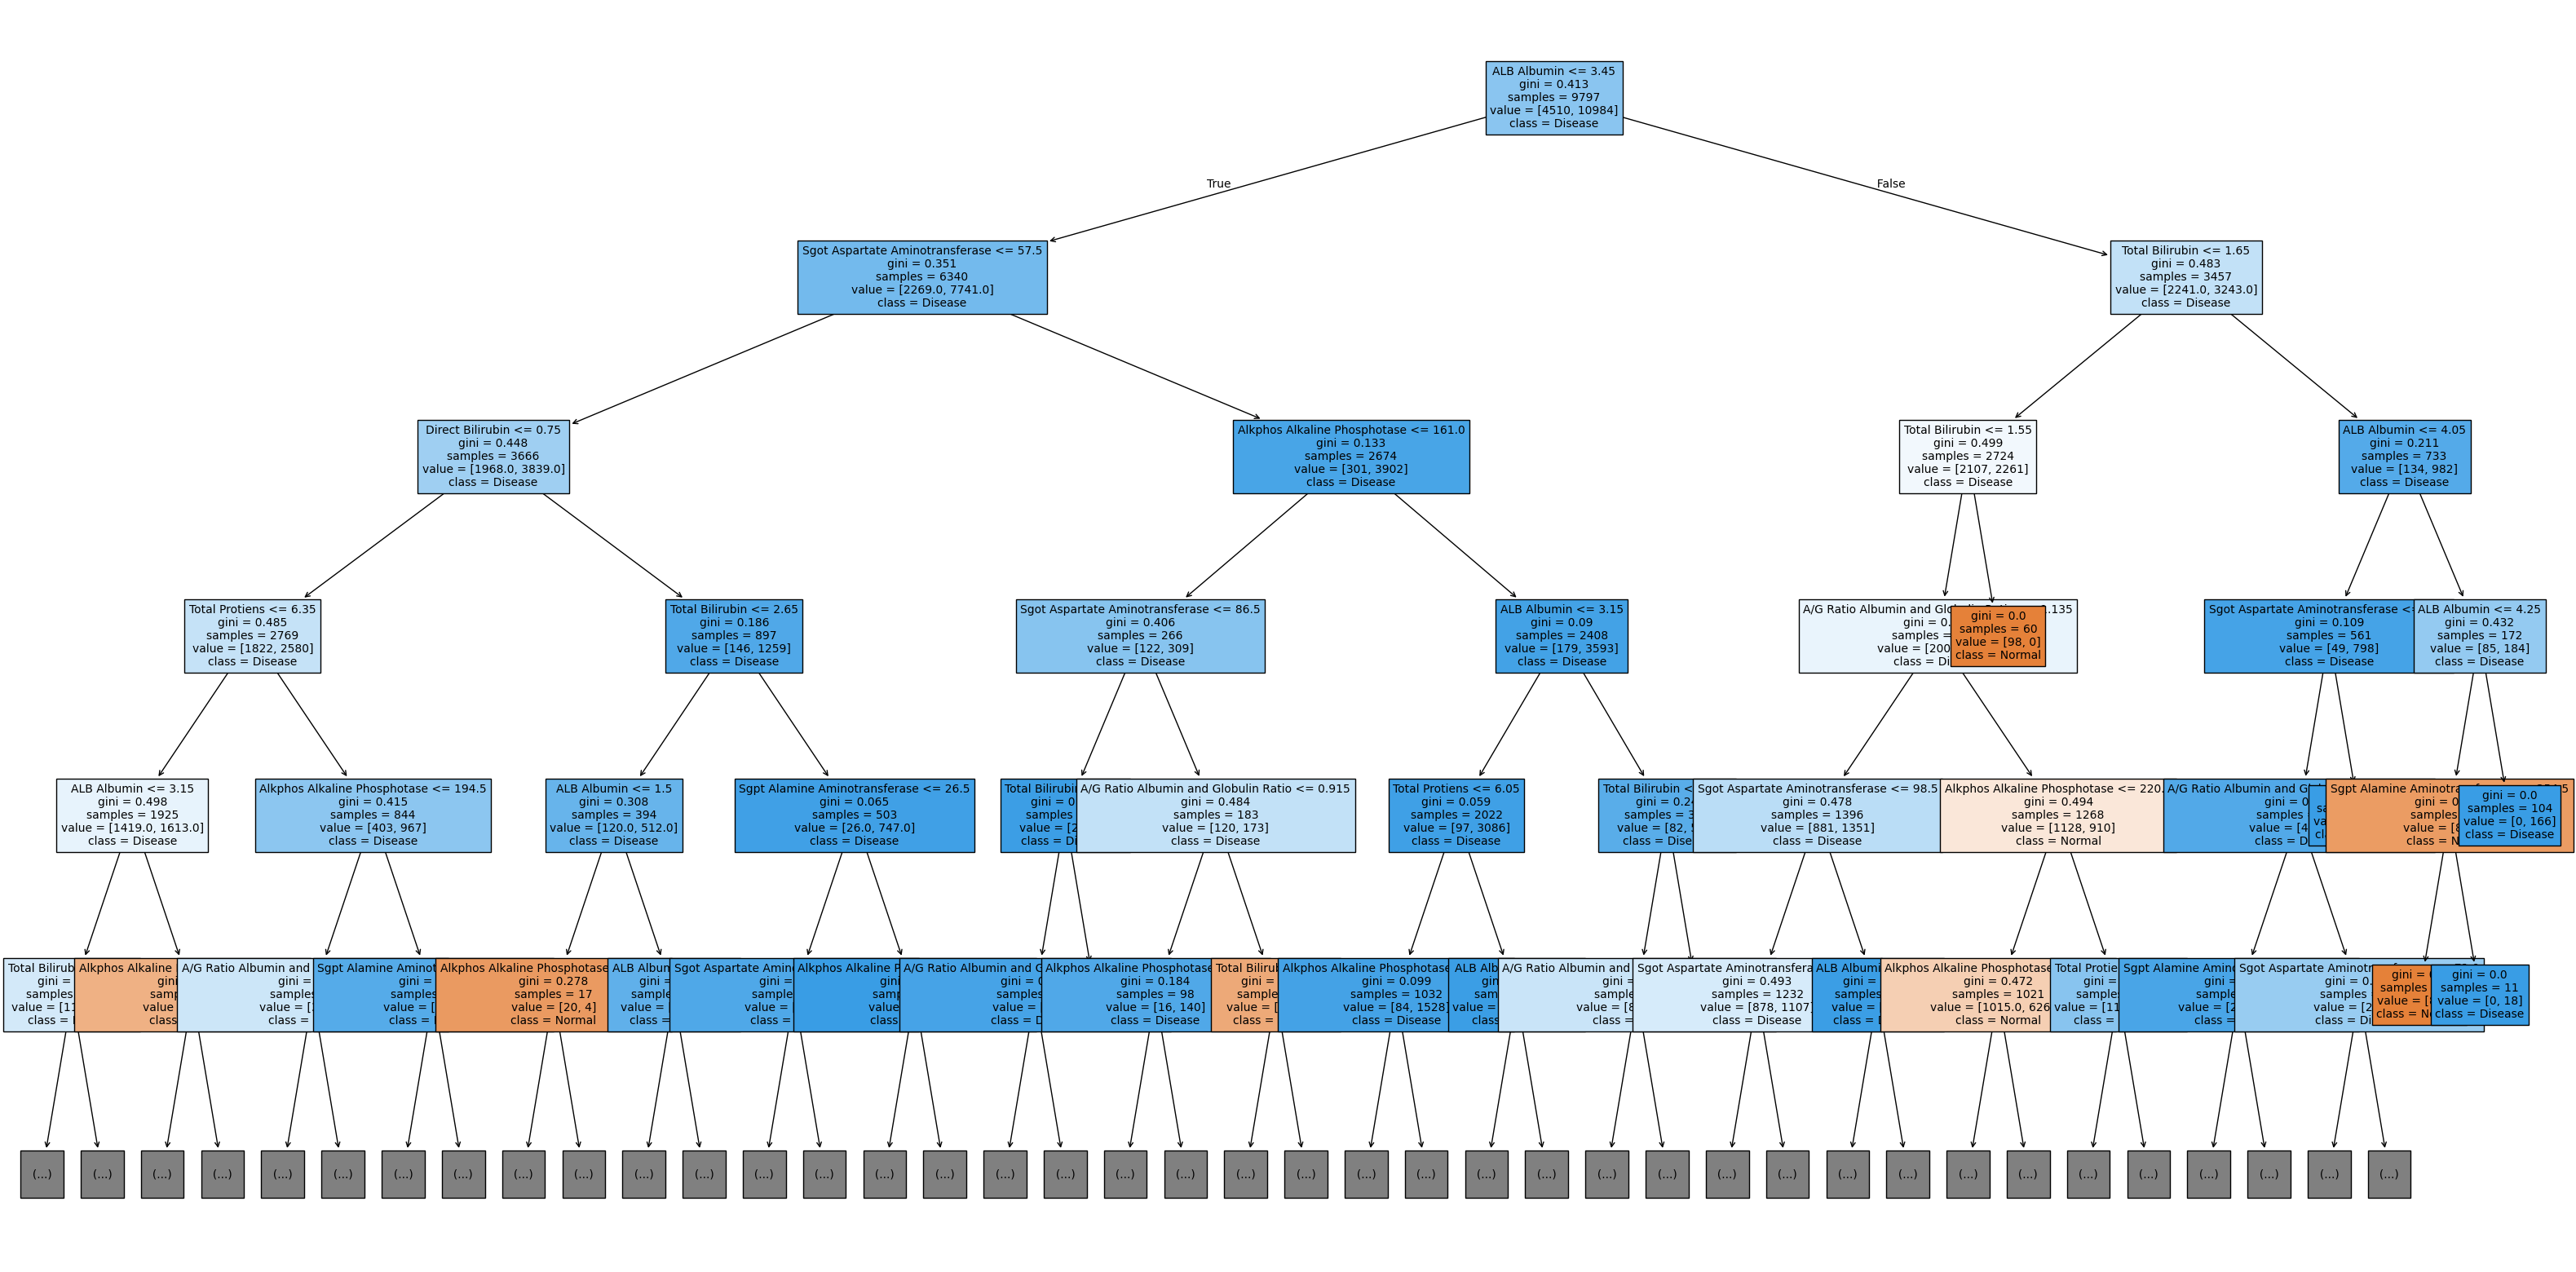

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,20))

plot_tree(
    model_randomforest.estimators_[0],
    filled=True,
    feature_names=X_train.columns,
    class_names=["Normal", "Disease"],
    max_depth=5,
    fontsize=10
)

plt.show()

In [ ]:
train_accuracy = model_randomforest.score(X_train, y_train)
test_accuracy = model_randomforest.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.9998709177746224
Test Accuracy: 0.9969024264326277


In [ ]:

results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

results.to_csv("../results/randomforest_results.csv", index=False)
report=classification_report(y_test,y_pred,output_dict=True)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../results/randomforest_classification_report.csv"
)